In [1]:
from tsut.core.pipeline.pipeline import Pipeline
from tsut.components.nodes.transforms.feature_selection.variance_filter import VarianceFilter, VarianceFilterConfig
from tsut.core.nodes.registry.node_registry import NODE_REGISTRY
%matplotlib ipympl
import pandas as pd

In [2]:
input = pd.read_csv("../data/fake_batch.csv")
output = pd.read_csv("../data/fake_target_df.csv")

In [3]:
pipe = Pipeline()

In [4]:
pipe.add_node(node_class_name="VarianceFilter", node_name="var_filter1", node_config=VarianceFilterConfig())
pipe.add_node(node_class_name="VarianceFilter", node_name="var_filter2", node_config=VarianceFilterConfig())

In [ ]:
NODE_REGISTRY.register(
    "VarianceFilter",
    VarianceFilter,
    VarianceFilterConfig,
)

In [6]:
pipe.add_edge("var_filter1", "var_filter2", {"output": "input"})

In [7]:
pipe.compile()

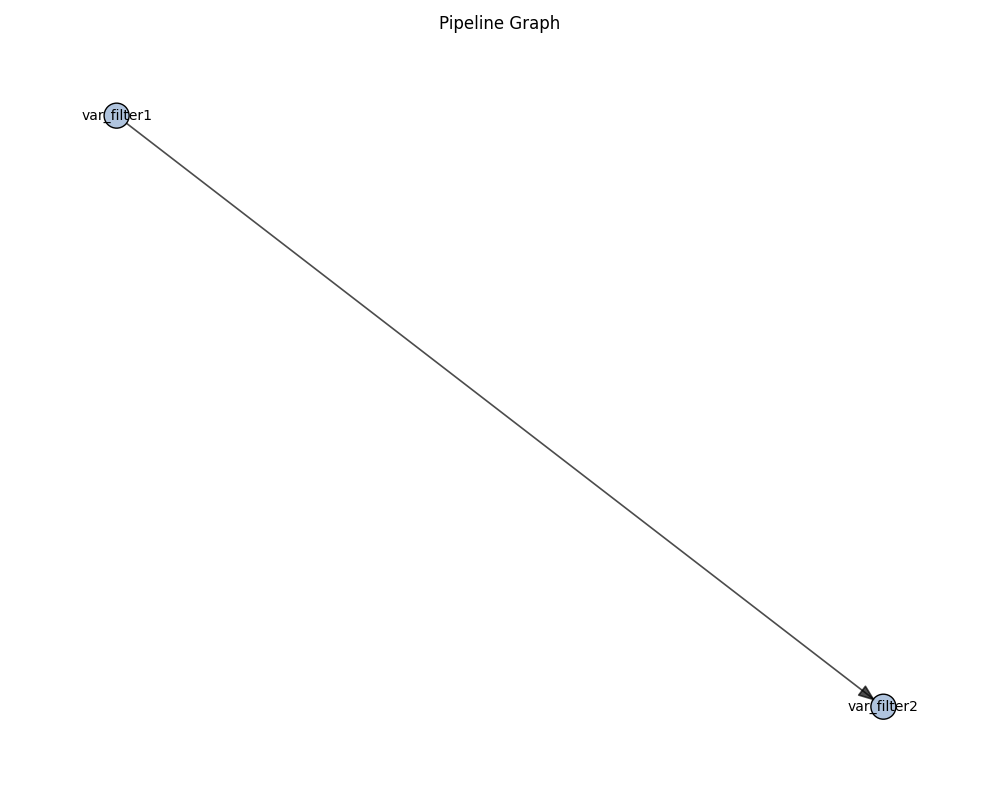

In [8]:
pipe.render()

In [9]:
config = VarianceFilterConfig()
var_filter2 = VarianceFilter(config=config)

In [10]:
var_filter2.fit({"input": input})

In [11]:
var_filter2.params

{'columns_to_filter': ['mean_CHG_TANBC60%',
  'mean_CHG_CARBON_TOTAL_LU',
  'mean_CHG_PARAFFIN_RATE',
  'mean_CHG_VC_RATE',
  'mean_CHG_CR2N_RATE',
  'mean_CHG_NI_RATE',
  'mean_CHG_MO2C_RATE',
  'mean_CHG_TANBC60_RATE',
  'mean_CHG_TIC_RATE',
  'mean_CHG_VC%',
  'mean_CHG_CR2N%',
  'mean_CHG_TIC%',
  'mean_CHG_MO2C%',
  'mean_CHG_NI%',
  'mean_CHG_%O_V',
  'mean_Co_FS_AS_V',
  'mean_Co_%O_V',
  'mean_VC_FS_AS_V',
  'mean_VC_%CTOT_V',
  'mean_VC_%CFREE_V',
  'mean_VC_%O_V',
  'mean_VC_%CTOT_LU',
  'mean_WC_FSASTM_V',
  'mean_WC_%CTOT_V',
  'mean_WC_%CFREE_V',
  'mean_WC_%O_V',
  'mean_WC_DPRESS_V',
  'mean_WC_%CTOT_LU',
  'mean_WC_D10_ASTM',
  'mean_CHG_FE%',
  'mean_CHG_FE_RATE',
  'total_pct_Par']}

In [12]:
var_filter2.transform({"input": input})

{'output':       output_batch_id    total_pct  ingredient_count  pct_entropy  \
 0                1090  1001.000000                 6     1.237044   
 1                1091  1001.000000                 7     1.051983   
 2                1092  1001.000000                 6     0.760430   
 3                1093  1001.000000                 7     1.265771   
 4                1094  1001.000000                 6     0.753528   
 ...               ...          ...               ...          ...   
 1241            87166     0.101788                13     1.905728   
 1242            87167     0.101788                13     1.895224   
 1243            87168     0.101820                14     2.095139   
 1244            87169     0.101820                14     2.129756   
 1245            87170     0.101820                14     2.099374   
 
       total_pct_CHG  total_pct_Co  total_pct_WC top1_element    top1_pct  \
 0        150.564320     73.000000    778.000000           WC  537.2636